# 21. Multi-Agent Causal Review Workflow

A multi-agent causal workflow is useful only if the agents create independent pressure on the analysis. If five agents all repeat the same shallow summary, the workflow is theatre. If each role checks a different failure mode, the workflow can become a practical review board.

In this notebook we build a small causal review board: a domain reviewer, an identification reviewer, a statistician, a code reviewer, a reporting reviewer, and an adjudicator. The board reviews a deliberately flawed causal memo, compares it with deterministic diagnostics, and decides whether the analysis is ready for a decision.

## Learning Goals

By the end of this notebook, you should be able to:

- Explain when multi-agent review helps causal analysis and when it adds noise.
- Create role-specific review rubrics for causal work.
- Build deterministic reviewers for variable timing, bad controls, overlap, estimator sensitivity, and overclaiming.
- Represent reviewer outputs as structured artifacts.
- Reconcile reviewer disagreement with an adjudication rule.
- Ask local LLMs to produce role-specific reviews, then score them against deterministic evidence.
- Compare model families on whether they catch causal review failures.

## Live Model Note

Multi-agent notebooks are brittle in two directions. First, model outputs vary across reruns and model families. Second, the workflow can make variability look like expertise: a weak model may sound more credible when it speaks as a named specialist.

We will treat role labels as prompts, not credentials. Each reviewer must produce structured findings, and each finding is checked against deterministic evidence where possible. We also clear loaded model memory between model families during comparisons, because these notebooks use large local models.

## 1. Setup

The running example is a targeted win-back discount for subscription customers. A proposed memo claims that the discount caused renewal lift, but the memo contains several common causal problems:

- It treats targeted assignment as if it were random.
- It controls for a post-treatment engagement variable.
- It ignores overlap.
- It overstates exploratory segment effects.
- It recommends rollout without capacity and guardrail checks.

In [1]:
import json
import re
import sys
import warnings
from copy import deepcopy
from pathlib import Path
from typing import Any, Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from IPython.display import Markdown, display
from pydantic import BaseModel, Field

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', context='notebook')

PROJECT_ROOT = Path.cwd()
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / 'notebooks' / '_shared' / 'local_llm.py').exists():
        PROJECT_ROOT = candidate
        break

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f'Project root: {PROJECT_ROOT}')

Project root: /home/apex/Documents/portfolio


In [2]:
RUN_LIVE_LOCAL_LLM = True
RUN_FULL_MODEL_COMPARISON = True
RUN_SCHEMA_REPAIR_RETRY = True

MODEL_ID = 'Qwen/Qwen2.5-14B-Instruct'
MAX_NEW_TOKENS = 2200
COMPACT_MAX_NEW_TOKENS = 900
TEMPERATURE = 0.0
SEED = 221
MODEL_COMPARISON_CASE_LIMIT = 3

try:
    import torch
    print(f'CUDA available to this kernel: {torch.cuda.is_available()}')
except Exception as exc:
    print(f'Torch availability check failed: {exc}')

CUDA available to this kernel: True


In [3]:
try:
    from notebooks._shared.local_llm import DEFAULT_MODELS_TO_COMPARE
except Exception:
    DEFAULT_MODELS_TO_COMPARE = [('Qwen 14B', MODEL_ID, 'strong local analysis')]

MODELS_TO_COMPARE = DEFAULT_MODELS_TO_COMPARE
pd.DataFrame(MODELS_TO_COMPARE, columns=['label', 'model_id', 'role'])

,label,model_id,role
0,Qwen 0.5B,Qwen/Qwen2.5-0.5B-Instruct,pipeline smoke test
1,Qwen 7B,Qwen/Qwen2.5-7B-Instruct,fast default
2,Qwen 14B,Qwen/Qwen2.5-14B-Instruct,strong local analysis
3,Qwen 32B,Qwen/Qwen2.5-32B-Instruct,scale comparison
4,Phi mini,microsoft/Phi-3.5-mini-instruct,compact non-Qwen comparison
5,Mistral 7B,mistralai/Mistral-7B-Instruct-v0.3,7B model-family comparison
6,Mistral Small 24B,mistralai/Mistral-Small-3.1-24B-Instruct-2503,strong non-Qwen comparison
7,Gemma 3 27B,google/gemma-3-27b-it,large non-Qwen comparison
8,Llama 3.1 8B,meta-llama/Meta-Llama-3.1-8B-Instruct,industry-standard instruct baseline


## 2. Why Multi-Agent Review?

A single causal reviewer often has blind spots. A domain expert may know the operational assignment process but not the estimator. A statistician may notice unstable weights but miss a post-treatment variable hidden behind an innocent name. A stakeholder may see the business risk but miss the identification assumption.

A useful multi-agent review separates concerns:

- **Domain reviewer:** Does the story match how the business actually works?
- **Identification reviewer:** Does the proposed design identify the estimand?
- **Statistician:** Are diagnostics, uncertainty, and estimator sensitivity handled correctly?
- **Code reviewer:** Does the code use the right variables and avoid leakage?
- **Reporting reviewer:** Does the memo overclaim or hide limitations?
- **Adjudicator:** Which concerns block the decision?

## 3. Project Brief and Flawed Memo

The flawed memo below is intentionally plausible. That is important. Most dangerous causal mistakes do not look absurd; they look like ordinary business analysis with one or two assumptions silently smuggled in.

In [4]:
project_brief = {
    'project_id': 'targeted_winback_discount_review_v1',
    'decision': 'Should the company expand targeted win-back discounts to more at-risk subscribers?',
    'unit': 'subscriber_account',
    'treatment': 'winback_discount_offer',
    'outcome': 'renewed_45d',
    'time_horizon': '45 days after discount eligibility',
    'assignment_process': 'Retention managers prioritized subscribers using churn-risk score, account value, recent complaints, and campaign capacity.',
    'business_guardrails': ['discount_cost_45d', 'support_minutes_after_offer', 'margin_45d'],
    'stakeholders': ['Retention operations', 'Finance', 'Customer success', 'Data science review'],
}

flawed_memo = """
The win-back discount caused renewal to increase because offered subscribers renewed at a higher rate than subscribers who did not receive the offer.
The treatment assignment can be analyzed like an experiment because both groups are subscribers eligible for retention outreach.
Our regression controls for churn risk, prior usage, customer segment, and support minutes after the offer, so the estimate is causal.
The effect is largest in enterprise customers, so we should immediately expand the program to all enterprise at-risk accounts.
There are no major limitations because the regression includes the important predictors of renewal.
""".strip()

print(json.dumps(project_brief, indent=2))
display(Markdown('### Flawed Memo Under Review'))
display(Markdown(flawed_memo))

{
  "project_id": "targeted_winback_discount_review_v1",
  "decision": "Should the company expand targeted win-back discounts to more at-risk subscribers?",
  "unit": "subscriber_account",
  "treatment": "winback_discount_offer",
  "outcome": "renewed_45d",
  "time_horizon": "45 days after discount eligibility",
  "assignment_process": "Retention managers prioritized subscribers using churn-risk score, account value, recent complaints, and campaign capacity.",
  "business_guardrails": [
    "discount_cost_45d",
    "support_minutes_after_offer",
    "margin_45d"
  ],
  "stakeholders": [
    "Retention operations",
    "Finance",
    "Customer success",
    "Data science review"
  ]
}


### Flawed Memo Under Review

The win-back discount caused renewal to increase because offered subscribers renewed at a higher rate than subscribers who did not receive the offer.
The treatment assignment can be analyzed like an experiment because both groups are subscribers eligible for retention outreach.
Our regression controls for churn risk, prior usage, customer segment, and support minutes after the offer, so the estimate is causal.
The effect is largest in enterprise customers, so we should immediately expand the program to all enterprise at-risk accounts.
There are no major limitations because the regression includes the important predictors of renewal.

## 4. Simulating the Review Dataset

The data-generating process includes targeted treatment assignment, pre-treatment confounding, post-treatment engagement, heterogeneous effects, and a margin guardrail. The analysis team does not get to use the true expected effect in a real project, but we keep it visible in the notebook to teach why the reviews matter.

In [5]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def simulate_winback_data(n=6200, seed=SEED):
    rng = np.random.default_rng(seed)
    segment = rng.choice(['consumer', 'smb', 'mid_market', 'enterprise'], size=n, p=[0.42, 0.30, 0.20, 0.08])
    segment_baseline = {'consumer': -0.20, 'smb': 0.00, 'mid_market': 0.18, 'enterprise': 0.26}
    segment_value = {'consumer': 55, 'smb': 110, 'mid_market': 260, 'enterprise': 720}

    tenure_months = rng.gamma(3.0, 5.2, size=n).clip(1, 72)
    prior_usage_30d = np.maximum(0, rng.normal(7.8 + 0.07 * tenure_months + np.vectorize(segment_baseline.get)(segment), 2.3, size=n))
    account_value = np.exp(rng.normal(3.7, 0.55, size=n)) * np.vectorize(segment_value.get)(segment) / 70
    recent_complaints = rng.poisson(np.exp(-0.55 + 0.12 * prior_usage_30d + 0.20 * (segment == 'enterprise')))

    churn_risk_score = sigmoid(
        0.95
        - 0.05 * tenure_months
        - 0.24 * prior_usage_30d
        + 0.20 * recent_complaints
        - 0.0009 * account_value
        + rng.normal(0, 0.65, size=n)
    )

    treatment_logit = (
        -1.6
        + 2.7 * churn_risk_score
        + 0.42 * (segment == 'enterprise')
        + 0.30 * (segment == 'mid_market')
        + 0.18 * recent_complaints
        + 0.0006 * account_value
        - 0.03 * prior_usage_30d
    )
    propensity_true = sigmoid(treatment_logit)
    winback_discount_offer = rng.binomial(1, propensity_true)

    baseline_renewal_logit = (
        0.35
        - 1.85 * churn_risk_score
        + 0.12 * prior_usage_30d
        + 0.015 * tenure_months
        + 0.0007 * account_value
        + np.vectorize(segment_baseline.get)(segment)
    )
    treatment_effect_logit = 0.36 + 0.16 * (segment == 'enterprise') + 0.09 * (churn_risk_score > 0.65)
    p0 = sigmoid(baseline_renewal_logit)
    p1 = sigmoid(baseline_renewal_logit + treatment_effect_logit)
    renewed_45d = rng.binomial(1, np.where(winback_discount_offer == 1, p1, p0))

    support_minutes_after_offer = np.maximum(
        0,
        rng.normal(12 + 20 * winback_discount_offer + 7 * churn_risk_score + 3 * recent_complaints, 8, size=n),
    )
    discount_cost_45d = winback_discount_offer * np.maximum(0, rng.normal(18 + 0.06 * account_value, 7, size=n))
    margin_45d = (
        0.42 * account_value * renewed_45d
        - discount_cost_45d
        - 0.8 * support_minutes_after_offer
        + rng.normal(0, 18, size=n)
    )

    return pd.DataFrame({
        'subscriber_id': np.arange(n),
        'segment': segment,
        'tenure_months': tenure_months,
        'prior_usage_30d': prior_usage_30d,
        'account_value': account_value,
        'recent_complaints': recent_complaints,
        'churn_risk_score': churn_risk_score,
        'winback_discount_offer': winback_discount_offer,
        'support_minutes_after_offer': support_minutes_after_offer,
        'discount_cost_45d': discount_cost_45d,
        'renewed_45d': renewed_45d,
        'margin_45d': margin_45d,
        'true_expected_effect': p1 - p0,
    })


df = simulate_winback_data()
df.head()

,subscriber_id,segment,tenure_months,prior_usage_30d,account_value,recent_complaints,churn_risk_score,winback_discount_offer,support_minutes_after_offer,discount_cost_45d,renewed_45d,margin_45d,true_expected_effect
0,0,smb,30.860314,9.944841,133.097031,2,0.033538,0,24.148661,0.000000,1,36.554825,0.031960
1,1,consumer,13.249964,8.545433,29.589540,4,0.320218,1,49.731496,17.102397,0,-50.843663,0.071277
2,2,mid_market,16.829915,9.482597,68.858462,2,0.209342,0,20.310278,0.000000,1,-31.397610,0.045107
3,3,smb,26.697655,9.925273,131.857688,1,0.079467,0,24.549051,0.000000,1,35.952929,0.035984
4,4,consumer,6.751255,4.916823,30.403367,3,0.413663,0,23.422804,0.000000,0,3.830226,0.088068


In [6]:
summary_by_treatment = (
    df.assign(offer_label=lambda d: np.where(d['winback_discount_offer'] == 1, 'offered discount', 'not offered'))
    .groupby('offer_label')
    .agg(
        accounts=('subscriber_id', 'size'),
        renewal_rate=('renewed_45d', 'mean'),
        churn_risk_score=('churn_risk_score', 'mean'),
        account_value=('account_value', 'mean'),
        recent_complaints=('recent_complaints', 'mean'),
        support_minutes_after_offer=('support_minutes_after_offer', 'mean'),
        margin_45d=('margin_45d', 'mean'),
    )
    .reset_index()
)
summary_by_treatment

,offer_label,accounts,renewal_rate,churn_risk_score,account_value,recent_complaints,support_minutes_after_offer,margin_45d
0,not offered,4353,0.780841,0.17646,105.356237,1.656559,18.181980,21.891401
1,offered discount,1847,0.809421,0.23609,123.377056,2.051976,39.642506,-12.557498


In [7]:
true_ate = df['true_expected_effect'].mean()
naive_difference = (
    df.loc[df['winback_discount_offer'] == 1, 'renewed_45d'].mean()
    - df.loc[df['winback_discount_offer'] == 0, 'renewed_45d'].mean()
)

pd.DataFrame([
    {'quantity': 'naive treated-control difference', 'value': naive_difference},
    {'quantity': 'true expected ATE visible only in simulation', 'value': true_ate},
])

,quantity,value
0,naive treated-control difference,0.028580
1,true expected ATE visible only in simulation,0.054743


## 5. Variable Dictionary

Variable timing is the first thing the review board checks. The memo controls for `support_minutes_after_offer`, which is post-treatment. That is the central bad-control issue.

In [8]:
variable_dictionary = pd.DataFrame([
    {'variable': 'segment', 'timing': 'pre', 'role': 'confounder', 'allowed_in_adjustment': True},
    {'variable': 'tenure_months', 'timing': 'pre', 'role': 'confounder', 'allowed_in_adjustment': True},
    {'variable': 'prior_usage_30d', 'timing': 'pre', 'role': 'confounder', 'allowed_in_adjustment': True},
    {'variable': 'account_value', 'timing': 'pre', 'role': 'confounder', 'allowed_in_adjustment': True},
    {'variable': 'recent_complaints', 'timing': 'pre', 'role': 'confounder', 'allowed_in_adjustment': True},
    {'variable': 'churn_risk_score', 'timing': 'pre', 'role': 'confounder', 'allowed_in_adjustment': True},
    {'variable': 'winback_discount_offer', 'timing': 'treatment', 'role': 'treatment', 'allowed_in_adjustment': False},
    {'variable': 'support_minutes_after_offer', 'timing': 'post', 'role': 'post_treatment_guardrail_or_mediator', 'allowed_in_adjustment': False},
    {'variable': 'discount_cost_45d', 'timing': 'post', 'role': 'guardrail', 'allowed_in_adjustment': False},
    {'variable': 'renewed_45d', 'timing': 'post', 'role': 'outcome', 'allowed_in_adjustment': False},
    {'variable': 'margin_45d', 'timing': 'post', 'role': 'guardrail_outcome', 'allowed_in_adjustment': False},
])

adjustment_set = variable_dictionary.loc[variable_dictionary['allowed_in_adjustment'], 'variable'].tolist()
post_treatment_variables = variable_dictionary.loc[variable_dictionary['timing'].eq('post'), 'variable'].tolist()
variable_dictionary

,variable,timing,role,allowed_in_adjustment
0,segment,pre,confounder,True
1,tenure_months,pre,confounder,True
2,prior_usage_30d,pre,confounder,True
3,account_value,pre,confounder,True
4,recent_complaints,pre,confounder,True
5,churn_risk_score,pre,confounder,True
6,winback_discount_offer,treatment,treatment,False
7,support_minutes_after_offer,post,post_treatment_guardrail_or_mediator,False
8,discount_cost_45d,post,guardrail,False
9,renewed_45d,post,outcome,False


## 6. Deterministic Diagnostic Tools

Before invoking LLM reviewers, we compute the facts they should reason from: covariate balance, overlap, effect estimates, a bad-control contrast, and guardrail movement.

In [9]:
def rhs(covariates):
    terms = []
    for covariate in covariates:
        terms.append('C(segment)' if covariate == 'segment' else covariate)
    return ' + '.join(terms)


def standardized_difference(data, variable, treatment='winback_discount_offer', weights=None):
    treated = data[treatment] == 1
    x1 = data.loc[treated, variable]
    x0 = data.loc[~treated, variable]
    if weights is None:
        m1, m0 = x1.mean(), x0.mean()
        v1, v0 = x1.var(ddof=1), x0.var(ddof=1)
    else:
        w1 = weights.loc[treated]
        w0 = weights.loc[~treated]
        m1 = np.average(x1, weights=w1)
        m0 = np.average(x0, weights=w0)
        v1 = np.average((x1 - m1) ** 2, weights=w1)
        v0 = np.average((x0 - m0) ** 2, weights=w0)
    pooled = np.sqrt((v1 + v0) / 2)
    return 0.0 if pooled == 0 or np.isnan(pooled) else float((m1 - m0) / pooled)


numeric_confounders = ['tenure_months', 'prior_usage_30d', 'account_value', 'recent_complaints', 'churn_risk_score']
raw_balance = pd.DataFrame([
    {'variable': variable, 'std_diff': standardized_difference(df, variable)}
    for variable in numeric_confounders
])
raw_balance['status'] = np.where(raw_balance['std_diff'].abs() <= 0.10, 'pass', 'review')
raw_balance

,variable,std_diff,status
0,tenure_months,-0.180603,review
1,prior_usage_30d,-0.175135,review
2,account_value,0.117844,review
3,recent_complaints,0.270160,review
4,churn_risk_score,0.410484,review


In [10]:
ps_formula = f"winback_discount_offer ~ {rhs(adjustment_set)}"
ps_model = smf.logit(ps_formula, data=df).fit(disp=False)
df_review = df.copy()
df_review['propensity'] = ps_model.predict(df_review).clip(0.02, 0.98)
df_review['ipw_weight'] = (
    df_review['winback_discount_offer'] / df_review['propensity']
    + (1 - df_review['winback_discount_offer']) / (1 - df_review['propensity'])
)

overlap = {
    'min_propensity': float(df_review['propensity'].min()),
    'max_propensity': float(df_review['propensity'].max()),
    'share_between_05_95': float(((df_review['propensity'] >= 0.05) & (df_review['propensity'] <= 0.95)).mean()),
    'effective_sample_size': float(df_review['ipw_weight'].sum() ** 2 / (df_review['ipw_weight'] ** 2).sum()),
}
overlap['status'] = 'pass' if overlap['share_between_05_95'] >= 0.95 else 'review'
print(json.dumps(overlap, indent=2))

{
  "min_propensity": 0.11201645864448151,
  "max_propensity": 0.8184646210499671,
  "share_between_05_95": 1.0,
  "effective_sample_size": 4687.840557113743,
  "status": "pass"
}


In [11]:
weighted_balance = pd.DataFrame([
    {'variable': variable, 'std_diff': standardized_difference(df_review, variable, weights=df_review['ipw_weight'])}
    for variable in numeric_confounders
])
weighted_balance['status'] = np.where(weighted_balance['std_diff'].abs() <= 0.10, 'pass', 'review')

balance_compare = raw_balance.rename(columns={'std_diff': 'raw_std_diff'})[['variable', 'raw_std_diff']].merge(
    weighted_balance.rename(columns={'std_diff': 'weighted_std_diff'})[['variable', 'weighted_std_diff']],
    on='variable',
)
balance_compare

,variable,raw_std_diff,weighted_std_diff
0,tenure_months,-0.180603,0.002628
1,prior_usage_30d,-0.175135,-0.010152
2,account_value,0.117844,0.002328
3,recent_complaints,0.270160,-0.000188
4,churn_risk_score,0.410484,0.003326


In [12]:
def fit_effect(formula, treatment='winback_discount_offer'):
    model = smf.ols(formula, data=df_review).fit(cov_type='HC1')
    return {
        'formula': formula,
        'estimate': float(model.params[treatment]),
        'std_error': float(model.bse[treatment]),
        'ci_low': float(model.conf_int().loc[treatment, 0]),
        'ci_high': float(model.conf_int().loc[treatment, 1]),
        'p_value': float(model.pvalues[treatment]),
    }


def estimate_ipw(data, outcome='renewed_45d', treatment='winback_discount_offer'):
    t = data[treatment]
    y = data[outcome]
    p = data['propensity']
    return float((t * y / p - (1 - t) * y / (1 - p)).mean())


def estimate_aipw(data, outcome='renewed_45d', treatment='winback_discount_offer', covariates=adjustment_set):
    treated = data[data[treatment] == 1]
    control = data[data[treatment] == 0]
    m1 = smf.ols(f"{outcome} ~ {rhs(covariates)}", data=treated).fit()
    m0 = smf.ols(f"{outcome} ~ {rhs(covariates)}", data=control).fit()
    mu1 = m1.predict(data)
    mu0 = m0.predict(data)
    t = data[treatment]
    y = data[outcome]
    p = data['propensity']
    return float((mu1 - mu0 + t * (y - mu1) / p - (1 - t) * (y - mu0) / (1 - p)).mean())


naive_result = {'method': 'naive_difference', 'estimate': naive_difference}
correct_regression = {'method': 'regression_pre_treatment', **fit_effect(f"renewed_45d ~ winback_discount_offer + {rhs(adjustment_set)}")}
bad_control_regression = {
    'method': 'bad_control_regression',
    **fit_effect(f"renewed_45d ~ winback_discount_offer + {rhs(adjustment_set + ['support_minutes_after_offer'])}"),
}
ipw_result = {'method': 'ipw', 'estimate': estimate_ipw(df_review)}
aipw_result = {'method': 'aipw', 'estimate': estimate_aipw(df_review)}
truth_result = {'method': 'true_expected_ate_synthetic_only', 'estimate': true_ate}

estimate_table = pd.DataFrame([naive_result, correct_regression, bad_control_regression, ipw_result, aipw_result, truth_result])
estimate_table

,method,estimate,formula,std_error,ci_low,ci_high,p_value
0,naive_difference,0.028580,NaN,NaN,NaN,NaN,NaN
1,regression_pre_treatment,0.054396,renewed_45d ~ winback_discount_offer + C(segme...,0.011054,0.032730,0.076061,8.614317e-07
2,bad_control_regression,0.042301,renewed_45d ~ winback_discount_offer + C(segme...,0.016888,0.009202,0.075401,1.225017e-02
3,ipw,0.049022,NaN,NaN,NaN,NaN,NaN
4,aipw,0.052813,NaN,NaN,NaN,NaN,NaN
5,true_expected_ate_synthetic_only,0.054743,NaN,NaN,NaN,NaN,NaN


In [13]:
margin_result = fit_effect(f"margin_45d ~ winback_discount_offer + {rhs(adjustment_set)}")
support_result = fit_effect(f"support_minutes_after_offer ~ winback_discount_offer + {rhs(adjustment_set)}")

guardrail_table = pd.DataFrame([
    {'guardrail': 'margin_45d', **margin_result},
    {'guardrail': 'support_minutes_after_offer', **support_result},
])
guardrail_table[['guardrail', 'estimate', 'ci_low', 'ci_high', 'p_value']]

,guardrail,estimate,ci_low,ci_high,p_value
0,margin_45d,-38.545578,-40.316944,-36.774211,0.0
1,support_minutes_after_offer,19.843458,19.396197,20.290720,0.0


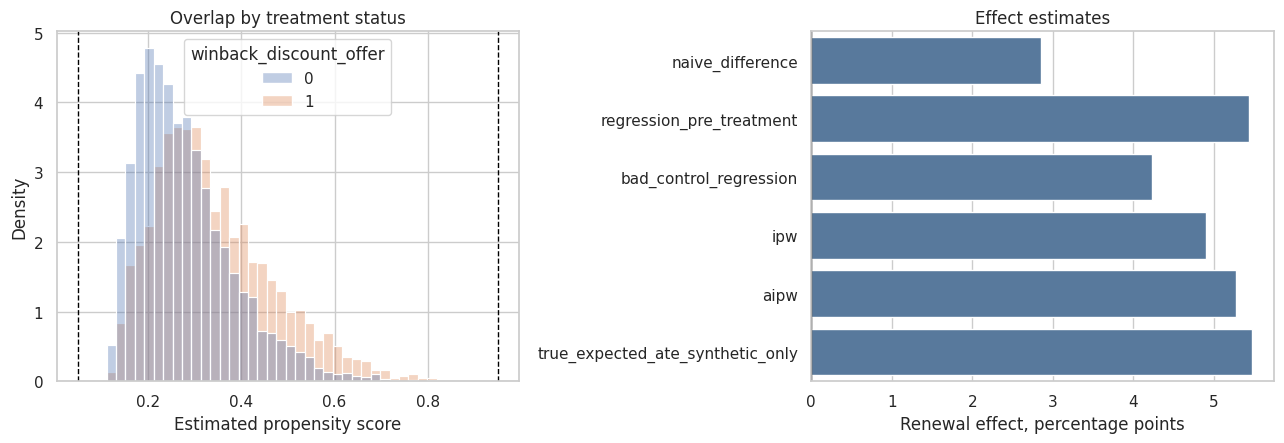

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

sns.histplot(
    data=df_review,
    x='propensity',
    hue='winback_discount_offer',
    bins=35,
    stat='density',
    common_norm=False,
    alpha=0.35,
    ax=axes[0],
)
axes[0].axvline(0.05, color='black', linestyle='--', linewidth=1)
axes[0].axvline(0.95, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Overlap by treatment status')
axes[0].set_xlabel('Estimated propensity score')

plot_estimates = estimate_table.copy()
plot_estimates['estimate_pp'] = 100 * plot_estimates['estimate']
sns.barplot(data=plot_estimates, x='estimate_pp', y='method', color='#4C78A8', ax=axes[1])
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_title('Effect estimates')
axes[1].set_xlabel('Renewal effect, percentage points')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## 7. Evidence Package for Review

A multi-agent review needs a shared evidence package. The agents can disagree about interpretation, but they should not disagree about which artifacts exist.

In [15]:
def clean_value(value):
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating, float)):
        if np.isnan(value):
            return None
        return float(value)
    if isinstance(value, dict):
        return {key: clean_value(val) for key, val in value.items() if clean_value(val) is not None}
    if isinstance(value, list):
        return [clean_value(item) for item in value]
    return value


def df_records(dataframe):
    return clean_value(dataframe.to_dict(orient='records'))


review_package = clean_value({
    'project_brief': project_brief,
    'flawed_memo': flawed_memo,
    'variable_dictionary': df_records(variable_dictionary),
    'raw_balance': df_records(raw_balance.round(4)),
    'weighted_balance': df_records(weighted_balance.round(4)),
    'overlap': overlap,
    'estimate_table': df_records(estimate_table.round(5)),
    'guardrail_table': df_records(guardrail_table[['guardrail', 'estimate', 'ci_low', 'ci_high', 'p_value']].round(5)),
    'known_for_teaching_only': {'true_expected_ate': true_ate},
    'brittleness_note': 'Multi-agent reviews are brittle because role prompts, model family, decoding, and agent ordering can change findings.',
})

print(json.dumps(review_package, indent=2)[:5000])

{
  "project_brief": {
    "project_id": "targeted_winback_discount_review_v1",
    "decision": "Should the company expand targeted win-back discounts to more at-risk subscribers?",
    "unit": "subscriber_account",
    "treatment": "winback_discount_offer",
    "outcome": "renewed_45d",
    "time_horizon": "45 days after discount eligibility",
    "assignment_process": "Retention managers prioritized subscribers using churn-risk score, account value, recent complaints, and campaign capacity.",
    "business_guardrails": [
      "discount_cost_45d",
      "support_minutes_after_offer",
      "margin_45d"
    ],
    "stakeholders": [
      "Retention operations",
      "Finance",
      "Customer success",
      "Data science review"
    ]
  },
  "flawed_memo": "The win-back discount caused renewal to increase because offered subscribers renewed at a higher rate than subscribers who did not receive the offer.\nThe treatment assignment can be analyzed like an experiment because both group

## 8. Deterministic Role Reviewers

The first review board is deterministic. Each reviewer follows a rubric and returns structured findings. This gives us a baseline for judging later LLM reviewers.

In [16]:
def make_review(role, decision, severity, findings, blocking_concerns, required_fixes):
    return {
        'role': role,
        'decision': decision,
        'severity': severity,
        'findings': findings,
        'blocking_concerns': blocking_concerns,
        'required_fixes': required_fixes,
    }


def domain_reviewer(package):
    memo = package['flawed_memo'].lower()
    findings = [
        'The memo does not discuss campaign capacity, discount cost, or finance guardrails before recommending expansion.',
        'The assignment process says retention managers prioritized accounts, so operational targeting is central to the story.',
    ]
    blocking = []
    if 'immediately expand' in memo or 'all enterprise' in memo:
        blocking.append('The memo recommends broad expansion before capacity and margin guardrails are reviewed.')
    return make_review('domain_reviewer', 'request_changes', 'high', findings, blocking, ['Add capacity, margin, and support-load guardrail review before rollout.'])


def identification_reviewer(package):
    memo = package['flawed_memo'].lower()
    findings = [
        'Treatment was targeted, so the design is observational rather than experimental.',
        '`support_minutes_after_offer` is post-treatment and should not be used as an adjustment variable for the renewal effect.',
        'The identifying assumption is conditional exchangeability after observed pre-treatment adjustment.',
    ]
    blocking = []
    if 'like an experiment' in memo:
        blocking.append('The memo incorrectly treats targeted assignment as experiment-like evidence.')
    if 'support minutes after the offer' in memo:
        blocking.append('The memo controls for a post-treatment variable.')
    return make_review('identification_reviewer', 'block_decision', 'critical', findings, blocking, ['Rewrite design as observational adjustment and exclude post-treatment controls.'])


def statistician_reviewer(package):
    estimates = pd.DataFrame(package['estimate_table'])
    plausible = estimates[estimates['method'].isin(['regression_pre_treatment', 'ipw', 'aipw'])]
    spread = plausible['estimate'].max() - plausible['estimate'].min()
    findings = [
        f"Overlap status is {package['overlap']['status']} with {package['overlap']['share_between_05_95']:.3f} of units in [0.05, 0.95].",
        f"Plausible adjusted estimates vary by {100 * spread:.2f} percentage points.",
        'The bad-control estimate should be shown only as a diagnostic warning, not as a preferred model.',
    ]
    blocking = []
    if package['overlap']['status'] != 'pass':
        blocking.append('Overlap is not adequate for a stable adjusted estimate.')
    if spread > 0.04:
        blocking.append('Adjusted estimators disagree enough to require sensitivity analysis.')
    return make_review('statistician_reviewer', 'request_changes', 'medium' if not blocking else 'high', findings, blocking, ['Report adjusted estimates with uncertainty and estimator sensitivity.'])


def code_reviewer(package):
    findings = [
        'The flawed memo implies a regression formula with a post-treatment variable.',
        'The preferred code path should construct adjustment variables from the variable dictionary, not from predictive convenience.',
        'The analysis should export an auditable evidence package rather than free-form notebook state only.',
    ]
    blocking = ['Regression code must remove `support_minutes_after_offer` from the adjustment set.']
    return make_review('code_reviewer', 'request_changes', 'high', findings, blocking, ['Enforce timing-based adjustment-set construction in code.'])


def reporting_reviewer(package):
    memo = package['flawed_memo'].lower()
    findings = [
        'The memo says the discount caused renewal lift without clearly stating observational assumptions.',
        'The memo hides uncertainty and does not state confidence intervals or estimator sensitivity.',
        'The memo presents enterprise segment expansion as definitive even though segment heterogeneity is exploratory.',
    ]
    blocking = []
    if 'caused' in memo and 'observational' not in memo:
        blocking.append('The memo overclaims causality from observational evidence.')
    if 'no major limitations' in memo:
        blocking.append('The memo falsely claims there are no major limitations.')
    return make_review('reporting_reviewer', 'request_changes', 'high', findings, blocking, ['Rewrite the memo with estimand, assumptions, uncertainty, guardrails, and limitations.'])


role_reviews = [
    domain_reviewer(review_package),
    identification_reviewer(review_package),
    statistician_reviewer(review_package),
    code_reviewer(review_package),
    reporting_reviewer(review_package),
]

pd.DataFrame(role_reviews)[['role', 'decision', 'severity', 'blocking_concerns', 'required_fixes']]

,role,decision,severity,blocking_concerns,required_fixes
0,domain_reviewer,request_changes,high,[The memo recommends broad expansion before ca...,"[Add capacity, margin, and support-load guardr..."
1,identification_reviewer,block_decision,critical,[The memo incorrectly treats targeted assignme...,[Rewrite design as observational adjustment an...
2,statistician_reviewer,request_changes,medium,[],[Report adjusted estimates with uncertainty an...
3,code_reviewer,request_changes,high,[Regression code must remove `support_minutes_...,[Enforce timing-based adjustment-set construct...
4,reporting_reviewer,request_changes,high,[The memo overclaims causality from observatio...,"[Rewrite the memo with estimand, assumptions, ..."


## 9. Adjudication

The adjudicator does not average opinions. It applies a decision rule. Critical identification errors block the decision even if other reviewers are satisfied.

In [17]:
def adjudicate_reviews(reviews):
    review_df = pd.DataFrame(reviews)
    blocking_items = []
    for review in reviews:
        for concern in review['blocking_concerns']:
            blocking_items.append({'role': review['role'], 'concern': concern})

    has_critical = review_df['severity'].isin(['critical']).any()
    has_block = len(blocking_items) > 0
    if has_critical or has_block:
        decision = 'not_ready_for_decision'
    elif review_df['decision'].eq('request_changes').any():
        decision = 'ready_after_revisions'
    else:
        decision = 'ready_for_decision'

    return {
        'adjudicated_decision': decision,
        'blocking_items': blocking_items,
        'required_next_steps': sorted(set(fix for review in reviews for fix in review['required_fixes'])),
        'review_count': len(reviews),
        'brittleness_note': 'A multi-agent board can still miss shared blind spots; deterministic checks and human review remain required.',
    }


adjudication = adjudicate_reviews(role_reviews)
print(json.dumps(adjudication, indent=2))

{
  "adjudicated_decision": "not_ready_for_decision",
  "blocking_items": [
    {
      "role": "domain_reviewer",
      "concern": "The memo recommends broad expansion before capacity and margin guardrails are reviewed."
    },
    {
      "role": "identification_reviewer",
      "concern": "The memo incorrectly treats targeted assignment as experiment-like evidence."
    },
    {
      "role": "identification_reviewer",
      "concern": "The memo controls for a post-treatment variable."
    },
    {
      "role": "code_reviewer",
      "concern": "Regression code must remove `support_minutes_after_offer` from the adjustment set."
    },
    {
      "role": "reporting_reviewer",
      "concern": "The memo overclaims causality from observational evidence."
    },
    {
      "role": "reporting_reviewer",
      "concern": "The memo falsely claims there are no major limitations."
    }
  ],
  "required_next_steps": [
    "Add capacity, margin, and support-load guardrail review before rol

In [18]:
def build_review_board_report(reviews, adjudication):
    lines = [
        '### Multi-Agent Causal Review Board Report',
        '',
        f"**Decision:** `{adjudication['adjudicated_decision']}`",
        '',
        '**Reviewer findings.**',
    ]
    for review in reviews:
        lines.append(f"\n**{review['role']}** - {review['decision']} ({review['severity']})")
        for finding in review['findings']:
            lines.append(f"- {finding}")
        if review['blocking_concerns']:
            lines.append('Blocking concerns:')
            for concern in review['blocking_concerns']:
                lines.append(f"- {concern}")
    lines.append('\n**Required next steps.**')
    for step in adjudication['required_next_steps']:
        lines.append(f"- {step}")
    lines.append('\n**Brittleness note.** Multi-agent agreement is not proof. The board should be rerun after revisions and checked by a human causal owner.')
    return '\n'.join(lines)


review_board_report = build_review_board_report(role_reviews, adjudication)
display(Markdown(review_board_report))

### Multi-Agent Causal Review Board Report

**Decision:** `not_ready_for_decision`

**Reviewer findings.**

**domain_reviewer** - request_changes (high)
- The memo does not discuss campaign capacity, discount cost, or finance guardrails before recommending expansion.
- The assignment process says retention managers prioritized accounts, so operational targeting is central to the story.
Blocking concerns:
- The memo recommends broad expansion before capacity and margin guardrails are reviewed.

**identification_reviewer** - block_decision (critical)
- Treatment was targeted, so the design is observational rather than experimental.
- `support_minutes_after_offer` is post-treatment and should not be used as an adjustment variable for the renewal effect.
- The identifying assumption is conditional exchangeability after observed pre-treatment adjustment.
Blocking concerns:
- The memo incorrectly treats targeted assignment as experiment-like evidence.
- The memo controls for a post-treatment variable.

**statistician_reviewer** - request_changes (medium)
- Overlap status is pass with 1.000 of units in [0.05, 0.95].
- Plausible adjusted estimates vary by 0.54 percentage points.
- The bad-control estimate should be shown only as a diagnostic warning, not as a preferred model.

**code_reviewer** - request_changes (high)
- The flawed memo implies a regression formula with a post-treatment variable.
- The preferred code path should construct adjustment variables from the variable dictionary, not from predictive convenience.
- The analysis should export an auditable evidence package rather than free-form notebook state only.
Blocking concerns:
- Regression code must remove `support_minutes_after_offer` from the adjustment set.

**reporting_reviewer** - request_changes (high)
- The memo says the discount caused renewal lift without clearly stating observational assumptions.
- The memo hides uncertainty and does not state confidence intervals or estimator sensitivity.
- The memo presents enterprise segment expansion as definitive even though segment heterogeneity is exploratory.
Blocking concerns:
- The memo overclaims causality from observational evidence.
- The memo falsely claims there are no major limitations.

**Required next steps.**
- Add capacity, margin, and support-load guardrail review before rollout.
- Enforce timing-based adjustment-set construction in code.
- Report adjusted estimates with uncertainty and estimator sensitivity.
- Rewrite design as observational adjustment and exclude post-treatment controls.
- Rewrite the memo with estimand, assumptions, uncertainty, guardrails, and limitations.

**Brittleness note.** Multi-agent agreement is not proof. The board should be rerun after revisions and checked by a human causal owner.

## 10. Optional LLM Role Reviews

Now we let a local model act as the role reviewers. We use one schema for all roles and compare the model's output with the deterministic review board.

Important: a role prompt does not make the model a real expert. It only focuses the model's attention. The audit still matters.

In [19]:
class RoleReview(BaseModel):
    role: Literal['domain_reviewer', 'identification_reviewer', 'statistician_reviewer', 'code_reviewer', 'reporting_reviewer']
    decision: Literal['approve', 'approve_with_cautions', 'request_changes', 'block_decision']
    severity: Literal['low', 'medium', 'high', 'critical']
    findings: list[str] = Field(min_length=2)
    blocking_concerns: list[str] = Field(default_factory=list)
    required_fixes: list[str] = Field(default_factory=list)
    evidence_used: list[str] = Field(default_factory=list)
    confidence: Literal['low', 'medium', 'high']


ROLE_FIELD_ALIASES = {
    'reviewer': 'role',
    'recommendation': 'decision',
    'risk_level': 'severity',
    'concerns': 'blocking_concerns',
    'blocks': 'blocking_concerns',
    'fixes': 'required_fixes',
    'evidence': 'evidence_used',
}

ROLE_VALUE_ALIASES = {
    'decision': {
        'request changes': 'request_changes',
        'needs changes': 'request_changes',
        'block': 'block_decision',
        'do not approve': 'block_decision',
        'approve with caution': 'approve_with_cautions',
        'approve with cautions': 'approve_with_cautions',
    },
    'severity': {'severe': 'high', 'blocker': 'critical'},
    'confidence': {'moderate': 'medium', 'cautious': 'medium', 'uncertain': 'low'},
}

ROLE_DEFAULTS = {
    'role': 'identification_reviewer',
    'decision': 'request_changes',
    'severity': 'high',
    'findings': [],
    'blocking_concerns': [],
    'required_fixes': [],
    'evidence_used': [],
    'confidence': 'medium',
}

REVIEW_ROLES = ['domain_reviewer', 'identification_reviewer', 'statistician_reviewer', 'code_reviewer', 'reporting_reviewer']

In [20]:
REVIEW_SYSTEM_MESSAGE = """
You are a careful causal inference review board member. Review only the evidence provided.
Do not invent variables. Do not call targeted observational assignment randomized. Return final JSON only.
""".strip()


def role_schema_prompt():
    return """
Return one RoleReview JSON object only.

Schema:
{
  "role": "domain_reviewer | identification_reviewer | statistician_reviewer | code_reviewer | reporting_reviewer",
  "decision": "approve | approve_with_cautions | request_changes | block_decision",
  "severity": "low | medium | high | critical",
  "findings": ["string", "string"],
  "blocking_concerns": ["string"],
  "required_fixes": ["string"],
  "evidence_used": ["string"],
  "confidence": "low | medium | high"
}
""".strip()


def build_role_prompt(role, package):
    role_instructions = {
        'domain_reviewer': 'Focus on operational assignment, capacity, finance guardrails, stakeholder decision risk, and whether the story matches the business process.',
        'identification_reviewer': 'Focus on estimand, treatment assignment, exchangeability, bad controls, post-treatment variables, and whether the design identifies the claim.',
        'statistician_reviewer': 'Focus on overlap, balance, estimator sensitivity, uncertainty, and whether diagnostics support the estimate.',
        'code_reviewer': 'Focus on whether variables are used according to timing, whether formulas leak post-treatment information, and whether artifacts are auditable.',
        'reporting_reviewer': 'Focus on overclaiming, uncertainty, limitations, segment claims, and whether the memo language matches the evidence.',
    }
    compact_package = {
        'project_brief': package['project_brief'],
        'flawed_memo': package['flawed_memo'],
        'variable_dictionary': package['variable_dictionary'],
        'overlap': package['overlap'],
        'raw_balance': package['raw_balance'],
        'weighted_balance': package['weighted_balance'],
        'estimate_table': package['estimate_table'],
        'guardrail_table': package['guardrail_table'],
        'brittleness_note': package['brittleness_note'],
    }
    return f"""
{role_schema_prompt()}

You are the `{role}`.
{role_instructions[role]}

Evidence package:
{json.dumps(compact_package, indent=2)}

Requirements:
- Cite evidence from the package in `evidence_used`.
- Mention causal workflow brittleness if relevant.
- Be conservative when the memo overclaims.
""".strip()


print(build_role_prompt('identification_reviewer', review_package)[:2600])

Return one RoleReview JSON object only.

Schema:
{
  "role": "domain_reviewer | identification_reviewer | statistician_reviewer | code_reviewer | reporting_reviewer",
  "decision": "approve | approve_with_cautions | request_changes | block_decision",
  "severity": "low | medium | high | critical",
  "findings": ["string", "string"],
  "blocking_concerns": ["string"],
  "required_fixes": ["string"],
  "evidence_used": ["string"],
  "confidence": "low | medium | high"
}

You are the `identification_reviewer`.
Focus on estimand, treatment assignment, exchangeability, bad controls, post-treatment variables, and whether the design identifies the claim.

Evidence package:
{
  "project_brief": {
    "project_id": "targeted_winback_discount_review_v1",
    "decision": "Should the company expand targeted win-back discounts to more at-risk subscribers?",
    "unit": "subscriber_account",
    "treatment": "winback_discount_offer",
    "outcome": "renewed_45d",
    "time_horizon": "45 days after d

In [21]:
try:
    from notebooks._shared.local_llm import clear_loaded_model_cache, local_chat
    from notebooks._shared.structured_outputs import parse_pydantic_output
except Exception as exc:
    clear_loaded_model_cache = None
    local_chat = None
    parse_pydantic_output = None
    print(f'Could not import shared LLM helpers: {exc}')


def release_model_memory():
    if clear_loaded_model_cache is None:
        return
    try:
        clear_loaded_model_cache()
    except Exception as exc:
        print(f'Could not clear loaded model cache: {exc}')

In [22]:
def parse_role_review(raw_output, expected_role):
    if parse_pydantic_output is None:
        raise RuntimeError('parse_pydantic_output is unavailable')
    defaults = {**ROLE_DEFAULTS, 'role': expected_role}
    return parse_pydantic_output(
        raw_output,
        RoleReview,
        scalar_fields=['role', 'decision', 'severity', 'confidence'],
        list_fields=['findings', 'blocking_concerns', 'required_fixes', 'evidence_used'],
        field_aliases=ROLE_FIELD_ALIASES,
        value_aliases=ROLE_VALUE_ALIASES,
        defaults=defaults,
    )


llm_role_reviews = []
llm_role_failures = []

if RUN_LIVE_LOCAL_LLM and local_chat is not None and parse_pydantic_output is not None:
    release_model_memory()
    try:
        for role in REVIEW_ROLES:
            print(f'Running role review: {role}')
            raw = local_chat(
                build_role_prompt(role, review_package),
                system_message=REVIEW_SYSTEM_MESSAGE,
                model_id=MODEL_ID,
                max_new_tokens=MAX_NEW_TOKENS,
                temperature=TEMPERATURE,
                seed=SEED,
                enabled=RUN_LIVE_LOCAL_LLM,
            )
            try:
                parsed = parse_role_review(raw, role)
                llm_role_reviews.append(parsed.parsed.model_dump())
                if parsed.notes:
                    print(f'{role} parser notes:', parsed.notes)
            except Exception as exc:
                llm_role_failures.append({'role': role, 'error': repr(exc), 'raw_preview': raw[:500]})
    finally:
        release_model_memory()
else:
    print('RUN_LIVE_LOCAL_LLM is False. Skipping live local role reviews.')

if llm_role_reviews:
    display(pd.DataFrame(llm_role_reviews)[['role', 'decision', 'severity', 'blocking_concerns', 'required_fixes', 'confidence']])
if llm_role_failures:
    display(pd.DataFrame(llm_role_failures))

Running role review: domain_reviewer
Running role review: identification_reviewer
Running role review: statistician_reviewer
Running role review: code_reviewer
Running role review: reporting_reviewer


,role,decision,severity,blocking_concerns,required_fixes,confidence
0,domain_reviewer,request_changes,medium,[The flawed memo incorrectly claims that the t...,[Clarify that the assignment process is not ra...,high
1,identification_reviewer,request_changes,medium,[The inclusion of 'support_minutes_after_offer...,[Remove 'support_minutes_after_offer' from the...,medium
2,statistician_reviewer,approve_with_cautions,medium,[],[Address raw imbalance in pre-treatment covari...,high
3,code_reviewer,request_changes,medium,[],[Remove 'support_minutes_after_offer' from the...,high
4,reporting_reviewer,request_changes,medium,[],[Clarify that the treatment assignment is not ...,high


## 11. Auditing LLM Role Reviews

A good role review should catch the same hard failures as the deterministic board. It does not need identical wording, but it should not miss the causal blockers.

In [23]:
def contains_any(text, patterns):
    text_lower = text.lower()
    return any(pattern.lower() in text_lower for pattern in patterns)


def score_role_reviews(reviews):
    if not reviews:
        return pd.DataFrame([{'criterion': 'parsed role reviews exist', 'passed': False, 'score': 0}])
    text_by_role = {review['role']: ' '.join(
        [review['decision'], review['severity'], ' '.join(review['findings']), ' '.join(review['blocking_concerns']), ' '.join(review['required_fixes']), ' '.join(review['evidence_used'])]
    ).lower() for review in reviews}
    all_text = ' '.join(text_by_role.values())
    checks = {
        'includes all five reviewer roles': set(text_by_role) == set(REVIEW_ROLES),
        'identification catches targeted observational assignment': contains_any(text_by_role.get('identification_reviewer', ''), ['targeted', 'observational', 'not randomized', 'not random']),
        'identification catches post-treatment bad control': contains_any(text_by_role.get('identification_reviewer', ''), ['post-treatment', 'post treatment', 'bad control', 'support_minutes_after_offer']),
        'statistics mentions overlap or balance': contains_any(text_by_role.get('statistician_reviewer', ''), ['overlap', 'balance', 'propensity', 'weighted']),
        'code review mentions formula or leakage': contains_any(text_by_role.get('code_reviewer', ''), ['formula', 'leak', 'post-treatment', 'support_minutes_after_offer']),
        'reporting catches overclaiming': contains_any(text_by_role.get('reporting_reviewer', ''), ['overclaim', 'caused', 'limitations', 'uncertainty']),
        'domain review mentions guardrails or capacity': contains_any(text_by_role.get('domain_reviewer', ''), ['capacity', 'guardrail', 'margin', 'finance', 'support']),
        'at least one role blocks decision': any(review['decision'] == 'block_decision' for review in reviews),
        'mentions brittleness or audit': contains_any(all_text, ['brittle', 'rerun', 'model output', 'audit', 'multi-agent']),
        'does not approve flawed memo outright': not any(review['decision'] == 'approve' and review['severity'] == 'low' for review in reviews),
    }
    return pd.DataFrame([
        {'criterion': key, 'passed': bool(value), 'score': int(bool(value))}
        for key, value in checks.items()
    ])


llm_role_review_score = score_role_reviews(llm_role_reviews)
llm_role_review_score

,criterion,passed,score
0,includes all five reviewer roles,True,1
1,identification catches targeted observational ...,True,1
2,identification catches post-treatment bad control,True,1
3,statistics mentions overlap or balance,True,1
4,code review mentions formula or leakage,True,1
5,reporting catches overclaiming,True,1
6,domain review mentions guardrails or capacity,True,1
7,at least one role blocks decision,False,0
8,mentions brittleness or audit,True,1
9,does not approve flawed memo outright,True,1


## 12. Optional All-Model Comparison

For the all-model comparison, we use compact review cases. Each model must produce a short adjudication: whether the memo is ready, which concerns block it, and which role should own the fix.

In [24]:
class CompactReviewAdjudication(BaseModel):
    decision: Literal['ready_for_decision', 'ready_after_revisions', 'not_ready_for_decision']
    primary_blocker: Literal['none', 'domain', 'identification', 'statistics', 'code', 'reporting']
    blocking_concerns: list[str] = Field(default_factory=list)
    required_fixes: list[str] = Field(default_factory=list)
    roles_that_must_review: list[str] = Field(default_factory=list)
    confidence: Literal['low', 'medium', 'high']


ADJ_FIELD_ALIASES = {
    'recommendation': 'decision',
    'blocker': 'primary_blocker',
    'concerns': 'blocking_concerns',
    'fixes': 'required_fixes',
    'review_roles': 'roles_that_must_review',
}

ADJ_VALUE_ALIASES = {
    'decision': {
        'not ready': 'not_ready_for_decision',
        'do not proceed': 'not_ready_for_decision',
        'block': 'not_ready_for_decision',
        'revise': 'ready_after_revisions',
        'ready after revisions': 'ready_after_revisions',
        'ready': 'ready_for_decision',
    },
    'primary_blocker': {
        'identification reviewer': 'identification',
        'statistician': 'statistics',
        'stats': 'statistics',
        'code reviewer': 'code',
        'reporting reviewer': 'reporting',
        'domain reviewer': 'domain',
        'no blocker': 'none',
    },
    'confidence': {'moderate': 'medium', 'cautious': 'medium', 'uncertain': 'low'},
}

ADJ_DEFAULTS = {
    'decision': 'not_ready_for_decision',
    'primary_blocker': 'identification',
    'blocking_concerns': [],
    'required_fixes': [],
    'roles_that_must_review': [],
    'confidence': 'medium',
}

In [25]:
COMPACT_REVIEW_CASES = [
    {
        'case_name': 'bad_control_targeted_assignment',
        'memo': flawed_memo,
        'facts': {
            'assignment': 'targeted by churn risk and account value',
            'bad_control': 'support_minutes_after_offer is post-treatment and included in memo regression',
            'overlap_status': overlap['status'],
        },
        'expected_decision': 'not_ready_for_decision',
        'expected_blocker': 'identification',
    },
    {
        'case_name': 'clean_randomized_holdout_review',
        'memo': 'A randomized holdout campaign estimated a 2.1 percentage point renewal lift with confidence intervals and guardrails. The memo recommends phased rollout with monitoring.',
        'facts': {
            'assignment': 'randomized holdout',
            'bad_control': 'none reported',
            'overlap_status': 'not applicable',
        },
        'expected_decision': 'ready_after_revisions',
        'expected_blocker': 'none',
    },
    {
        'case_name': 'weak_overlap_observational_review',
        'memo': 'A targeted offer analysis uses propensity weighting, but treated customers have propensity scores above 0.90 while most controls are below 0.20. The memo recommends full rollout.',
        'facts': {
            'assignment': 'targeted observational assignment',
            'bad_control': 'none reported',
            'overlap_status': 'review; severe lack of common support',
        },
        'expected_decision': 'not_ready_for_decision',
        'expected_blocker': 'statistics',
    },
]

COMPACT_REVIEW_CASES

[{'case_name': 'bad_control_targeted_assignment',
  'memo': 'The win-back discount caused renewal to increase because offered subscribers renewed at a higher rate than subscribers who did not receive the offer.\nThe treatment assignment can be analyzed like an experiment because both groups are subscribers eligible for retention outreach.\nOur regression controls for churn risk, prior usage, customer segment, and support minutes after the offer, so the estimate is causal.\nThe effect is largest in enterprise customers, so we should immediately expand the program to all enterprise at-risk accounts.\nThere are no major limitations because the regression includes the important predictors of renewal.',
  'facts': {'assignment': 'targeted by churn risk and account value',
   'bad_control': 'support_minutes_after_offer is post-treatment and included in memo regression',
   'overlap_status': 'pass'},
  'expected_decision': 'not_ready_for_decision',
  'expected_blocker': 'identification'},
 {'

In [26]:
def compact_adjudication_prompt(case):
    return f"""
Return one CompactReviewAdjudication JSON object only.

Schema:
{{
  "decision": "ready_for_decision | ready_after_revisions | not_ready_for_decision",
  "primary_blocker": "none | domain | identification | statistics | code | reporting",
  "blocking_concerns": ["string"],
  "required_fixes": ["string"],
  "roles_that_must_review": ["string"],
  "confidence": "low | medium | high"
}}

Case:
{json.dumps(case, indent=2)}

Rules:
- Be conservative about causal identification.
- A post-treatment control in an observational causal model is a blocker.
- Weak overlap is a blocker for a rollout recommendation.
- Mention multi-agent review brittleness or auditability when relevant.
""".strip()


def parse_compact_adjudication(raw_output):
    if parse_pydantic_output is None:
        raise RuntimeError('parse_pydantic_output is unavailable')
    return parse_pydantic_output(
        raw_output,
        CompactReviewAdjudication,
        scalar_fields=['decision', 'primary_blocker', 'confidence'],
        list_fields=['blocking_concerns', 'required_fixes', 'roles_that_must_review'],
        field_aliases=ADJ_FIELD_ALIASES,
        value_aliases=ADJ_VALUE_ALIASES,
        defaults=ADJ_DEFAULTS,
    )


def score_compact_adjudication(adjudication, case):
    text = ' '.join([
        adjudication.decision,
        adjudication.primary_blocker,
        ' '.join(adjudication.blocking_concerns),
        ' '.join(adjudication.required_fixes),
        ' '.join(adjudication.roles_that_must_review),
    ]).lower()
    checks = {
        'decision matches expected': adjudication.decision == case['expected_decision'],
        'primary blocker matches expected': adjudication.primary_blocker == case['expected_blocker'],
        'requires at least one review role': len(adjudication.roles_that_must_review) >= 1 or adjudication.primary_blocker == 'none',
        'mentions causal reason': contains_any(text, ['causal', 'identification', 'overlap', 'post-treatment', 'randomized', 'guardrail']),
        'mentions brittleness or auditability': contains_any(text, ['brittle', 'audit', 'multi-agent', 'review', 'rerun']),
    }
    return int(sum(checks.values())), checks

In [27]:
def run_all_model_review_comparison(models_to_compare=MODELS_TO_COMPARE, cases=COMPACT_REVIEW_CASES):
    rows = []
    failures = []
    selected_cases = cases[:MODEL_COMPARISON_CASE_LIMIT]
    if local_chat is None or parse_pydantic_output is None:
        return pd.DataFrame(), [{'error': 'shared LLM helpers unavailable'}]

    for label, model_id, role in models_to_compare:
        release_model_memory()
        print(f'Running {label}: {model_id}')
        try:
            for case in selected_cases:
                try:
                    raw = local_chat(
                        compact_adjudication_prompt(case),
                        system_message=REVIEW_SYSTEM_MESSAGE,
                        model_id=model_id,
                        max_new_tokens=COMPACT_MAX_NEW_TOKENS,
                        temperature=TEMPERATURE,
                        seed=SEED,
                        enabled=True,
                    )
                    parsed = parse_compact_adjudication(raw)
                    score, checks = score_compact_adjudication(parsed.parsed, case)
                    rows.append({
                        'model': label,
                        'model_id': model_id,
                        'role': role,
                        'case': case['case_name'],
                        'decision': parsed.parsed.decision,
                        'primary_blocker': parsed.parsed.primary_blocker,
                        'score': score,
                        'max_score': len(checks),
                        'failed_checks': ', '.join([key for key, passed in checks.items() if not passed]),
                        'parser_notes': '; '.join(parsed.notes),
                    })
                except Exception as exc:
                    failures.append({'model': label, 'model_id': model_id, 'case': case['case_name'], 'error': repr(exc)})
        finally:
            release_model_memory()
    return pd.DataFrame(rows), failures


if RUN_FULL_MODEL_COMPARISON and RUN_LIVE_LOCAL_LLM:
    review_model_comparison, review_model_failures = run_all_model_review_comparison()
else:
    review_model_comparison = pd.DataFrame()
    review_model_failures = []
    print('Full model comparison skipped. Set RUN_FULL_MODEL_COMPARISON and RUN_LIVE_LOCAL_LLM to True to run it.')

Running Qwen 0.5B: Qwen/Qwen2.5-0.5B-Instruct
Running Qwen 7B: Qwen/Qwen2.5-7B-Instruct
Running Qwen 14B: Qwen/Qwen2.5-14B-Instruct
Running Qwen 32B: Qwen/Qwen2.5-32B-Instruct
Running Phi mini: microsoft/Phi-3.5-mini-instruct


[transformers] This model config has set a `rope_parameters['original_max_position_embeddings']` field, to be used together with `max_position_embeddings` to determine a scaling factor. Please set the `factor` field of `rope_parameters`with this ratio instead -- we recommend the use of this field over `original_max_position_embeddings`, as it is compatible with most model architectures.


Running Mistral 7B: mistralai/Mistral-7B-Instruct-v0.3
Running Mistral Small 24B: mistralai/Mistral-Small-3.1-24B-Instruct-2503


[transformers] The tied weights mapping and config for this model specifies to tie model.language_model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Running Gemma 3 27B: google/gemma-3-27b-it
Running Llama 3.1 8B: meta-llama/Meta-Llama-3.1-8B-Instruct


In [28]:
if len(review_model_comparison):
    display(review_model_comparison.sort_values(['score', 'model', 'case'], ascending=[False, True, True]).reset_index(drop=True))
else:
    print('No model-comparison results yet.')

,model,model_id,role,case,decision,primary_blocker,score,max_score,failed_checks,parser_notes
0,Llama 3.1 8B,meta-llama/Meta-Llama-3.1-8B-Instruct,industry-standard instruct baseline,bad_control_targeted_assignment,not_ready_for_decision,identification,5,5,,
1,Llama 3.1 8B,meta-llama/Meta-Llama-3.1-8B-Instruct,industry-standard instruct baseline,weak_overlap_observational_review,not_ready_for_decision,statistics,5,5,,
2,Qwen 0.5B,Qwen/Qwen2.5-0.5B-Instruct,pipeline smoke test,bad_control_targeted_assignment,not_ready_for_decision,identification,5,5,,Invalid JSON: expected value at line 1 column ...
3,Qwen 0.5B,Qwen/Qwen2.5-0.5B-Instruct,pipeline smoke test,weak_overlap_observational_review,not_ready_for_decision,statistics,5,5,,Invalid JSON: expected value at line 1 column ...
4,Gemma 3 27B,google/gemma-3-27b-it,large non-Qwen comparison,bad_control_targeted_assignment,not_ready_for_decision,identification,4,5,mentions brittleness or auditability,Invalid JSON: expected value at line 1 column ...
5,Gemma 3 27B,google/gemma-3-27b-it,large non-Qwen comparison,weak_overlap_observational_review,not_ready_for_decision,statistics,4,5,mentions brittleness or auditability,Invalid JSON: expected value at line 1 column ...
6,Mistral 7B,mistralai/Mistral-7B-Instruct-v0.3,7B model-family comparison,bad_control_targeted_assignment,not_ready_for_decision,identification,4,5,mentions brittleness or auditability,
7,Mistral Small 24B,mistralai/Mistral-Small-3.1-24B-Instruct-2503,strong non-Qwen comparison,bad_control_targeted_assignment,not_ready_for_decision,identification,4,5,mentions brittleness or auditability,Invalid JSON: expected value at line 1 column ...
8,Mistral Small 24B,mistralai/Mistral-Small-3.1-24B-Instruct-2503,strong non-Qwen comparison,weak_overlap_observational_review,not_ready_for_decision,statistics,4,5,mentions brittleness or auditability,Invalid JSON: expected value at line 1 column ...
9,Phi mini,microsoft/Phi-3.5-mini-instruct,compact non-Qwen comparison,bad_control_targeted_assignment,not_ready_for_decision,identification,4,5,mentions brittleness or auditability,


In [29]:
if len(review_model_comparison):
    summary = (
        review_model_comparison
        .groupby(['model', 'model_id', 'role'], as_index=False)
        .agg(mean_score=('score', 'mean'), min_score=('score', 'min'), cases=('case', 'nunique'))
        .sort_values(['mean_score', 'min_score'], ascending=False)
    )
    display(summary)
else:
    print('No model-comparison summary yet.')

if review_model_failures:
    display(pd.DataFrame(review_model_failures))
else:
    print('No failed model details because the full comparison was skipped or all calls parsed.')

,model,model_id,role,mean_score,min_score,cases
5,Qwen 0.5B,Qwen/Qwen2.5-0.5B-Instruct,pipeline smoke test,5.000000,5,2
7,Qwen 32B,Qwen/Qwen2.5-32B-Instruct,scale comparison,4.000000,4,3
1,Llama 3.1 8B,meta-llama/Meta-Llama-3.1-8B-Instruct,industry-standard instruct baseline,4.000000,2,3
4,Phi mini,microsoft/Phi-3.5-mini-instruct,compact non-Qwen comparison,3.666667,3,3
8,Qwen 7B,Qwen/Qwen2.5-7B-Instruct,fast default,3.666667,3,3
2,Mistral 7B,mistralai/Mistral-7B-Instruct-v0.3,7B model-family comparison,3.333333,3,3
0,Gemma 3 27B,google/gemma-3-27b-it,large non-Qwen comparison,3.333333,2,3
3,Mistral Small 24B,mistralai/Mistral-Small-3.1-24B-Instruct-2503,strong non-Qwen comparison,3.333333,2,3
6,Qwen 14B,Qwen/Qwen2.5-14B-Instruct,strong local analysis,3.333333,2,3


,model,model_id,case,error
0,Qwen 0.5B,Qwen/Qwen2.5-0.5B-Instruct,clean_randomized_holdout_review,ValueError('No valid CompactReviewAdjudication...


## 13. Multi-Agent Review Checklist

A causal review board is useful when it has structure:

1. Every role has a specific failure mode to check.
2. Reviewers use a shared evidence package.
3. Findings are structured and auditable.
4. Critical identification concerns can block the decision.
5. The adjudicator applies a rule rather than averaging opinions.
6. Deterministic diagnostics anchor the debate.
7. LLM-generated reviews are scored against known evidence.
8. Disagreement is preserved, not hidden.
9. Model memory is cleared between large model calls.
10. The workflow explicitly acknowledges brittleness across reruns, prompts, role ordering, and model families.

## 14. Exercises

1. Add a fairness reviewer who checks whether the discount policy changes access across customer segments.
2. Create a finance reviewer who focuses only on margin and discount-cost guardrails.
3. Modify the flawed memo so it does not include the post-treatment control. Which reviewers still request changes?
4. Make overlap poor by assigning discounts almost exclusively to high-risk customers. How does the statistician review change?
5. Run the all-model comparison and identify which models miss the bad-control blocker.
6. Change the adjudication rule so two high-severity concerns are enough to block even without a critical concern.

## 15. Key Takeaways

- Multi-agent review is valuable when roles are genuinely different and tied to concrete failure modes.
- Role labels do not make an LLM reliable; structured rubrics and deterministic evidence do.
- Identification blockers should not be averaged away by reassuring comments from other agents.
- A shared evidence package is the center of the workflow.
- Multi-agent causal workflows are brittle because prompts, role order, model choice, and adjudication rules can change the outcome. Treat that brittleness as a system property to audit.